In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


# Load Data

In [2]:
data = pd.read_csv('/Users/vydhyamvishnusai/DECISION_TREE_IMPEMENTATION/Telecom_Customer_Churn (5).csv')

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

# Sweetviz

In [5]:
!pip install sweetviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 5.9 MB/s  0:00:025.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [sweetviz]


In [6]:
import sweetviz as sv

report = sv.analyze(data)
report.show_html("sweetviz_report.html")

                                             |      | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Data Tranformation

In [15]:
if 'customerID' in data.columns:
    data.set_index('customerID', inplace=True)

In [14]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce').fillna(0).astype(int)

# Label Encoding

In [19]:
from sklearn.preprocessing import LabelEncoder 

encode = data[['gender', 'Partner', 'Dependents',
         'PhoneService', 'MultipleLines', 'InternetService',
         'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
         'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
        'PaymentMethod', 'Churn']]
le = LabelEncoder()
for column in encode:
    data[column] = le.fit_transform(data[column])

In [20]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29,0
5575-GNVDE,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889,0
3668-QPYBK,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108,1
7795-CFOCW,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840,0
9237-HQITU,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151,1


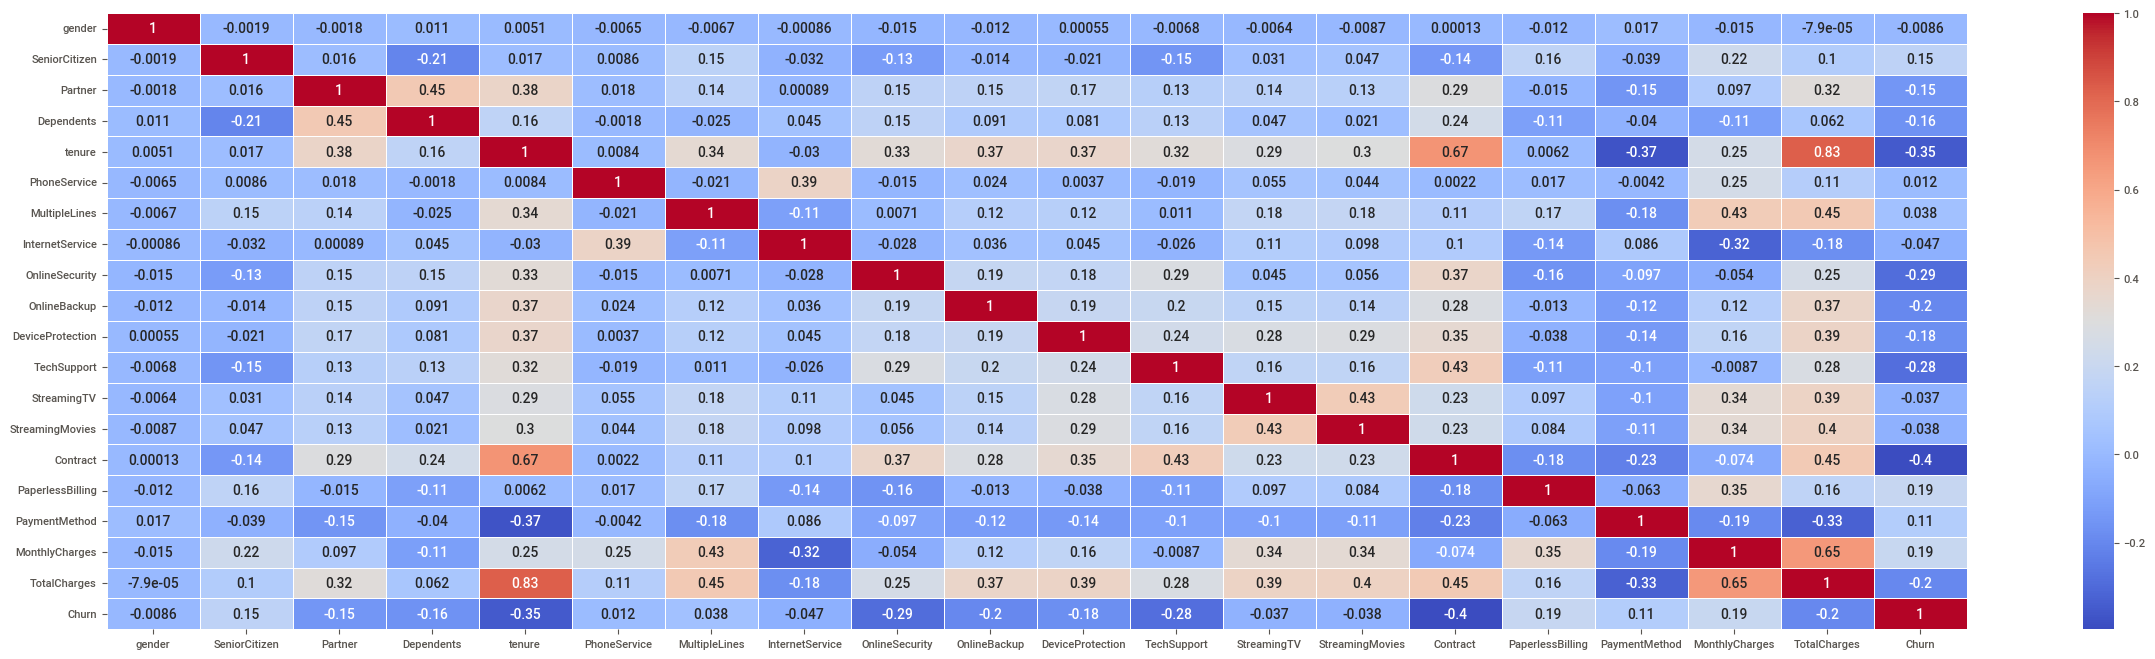

In [23]:
plt.figure(figsize = (30,8))
sns.heatmap(data.corr(),annot = True,  linewidth = 0.5, cmap = 'coolwarm')
plt.show()

# Decision Tree

In [25]:
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report 
from sklearn.metrics import confusion_matrix

In [27]:
x = data[['PhoneService','MultipleLines','PaperlessBilling','PaymentMethod','MonthlyCharges']]
y = data['Churn']

In [28]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [29]:
dt = DecisionTreeClassifier(criterion = "entropy", random_state = 42)
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [31]:
train_prediction = dt.predict(x_train)
test_prediction = dt.predict(x_test)

In [32]:
train_accuracy = accuracy_score(y_train, train_prediction)
test_accuracy = accuracy_score(y_test, test_prediction)

In [33]:
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9359
Testing Accuracy: 0.7012


# Confusion Matrix

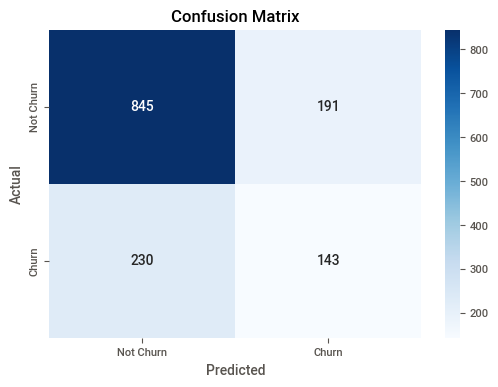

In [39]:
cm = confusion_matrix(y_test, test_prediction)

plt.figure(figsize = (6,4))
sns.heatmap(cm, annot = True,fmt = 'd',cmap = 'Blues' , xticklabels = ["Not Churn", "Churn"], yticklabels = ["Not Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report 

In [40]:
print("Classification Report (Testing Data):\n")
print(classification_report(y_test, test_prediction))

Classification Report (Testing Data):

              precision    recall  f1-score   support

           0       0.79      0.82      0.80      1036
           1       0.43      0.38      0.40       373

    accuracy                           0.70      1409
   macro avg       0.61      0.60      0.60      1409
weighted avg       0.69      0.70      0.70      1409



# Plotting Decision Tree

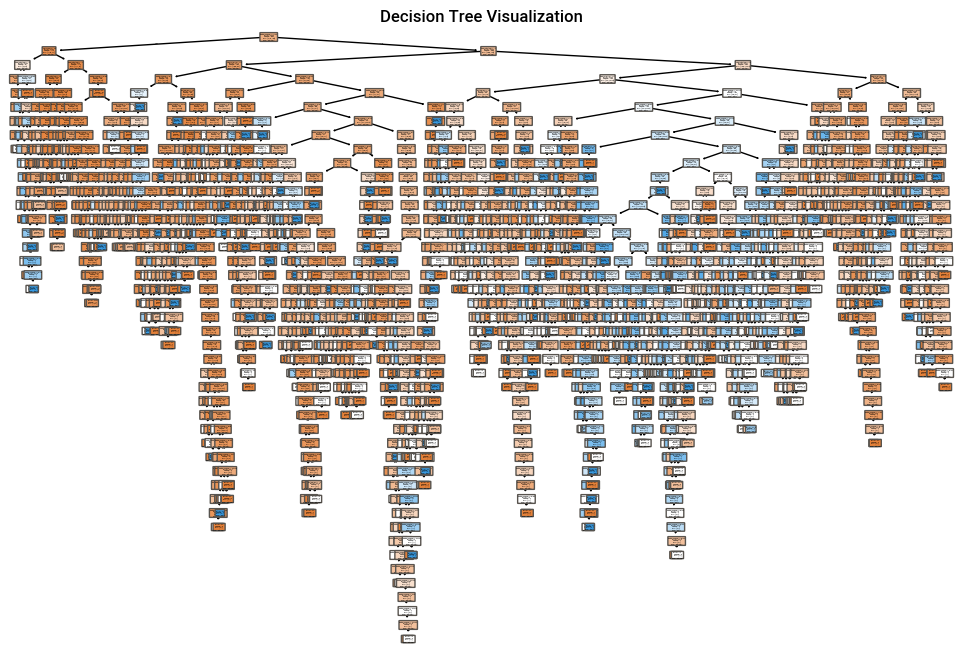

In [41]:
from sklearn.tree import plot_tree
plt.figure(figsize = (12,8))
plot_tree(dt, filled = True, feature_names = x_train.columns, class_names = ["Not Churn", "Churn"], rounded = True)
plt.title("Decision Tree Visualization")
plt.show()

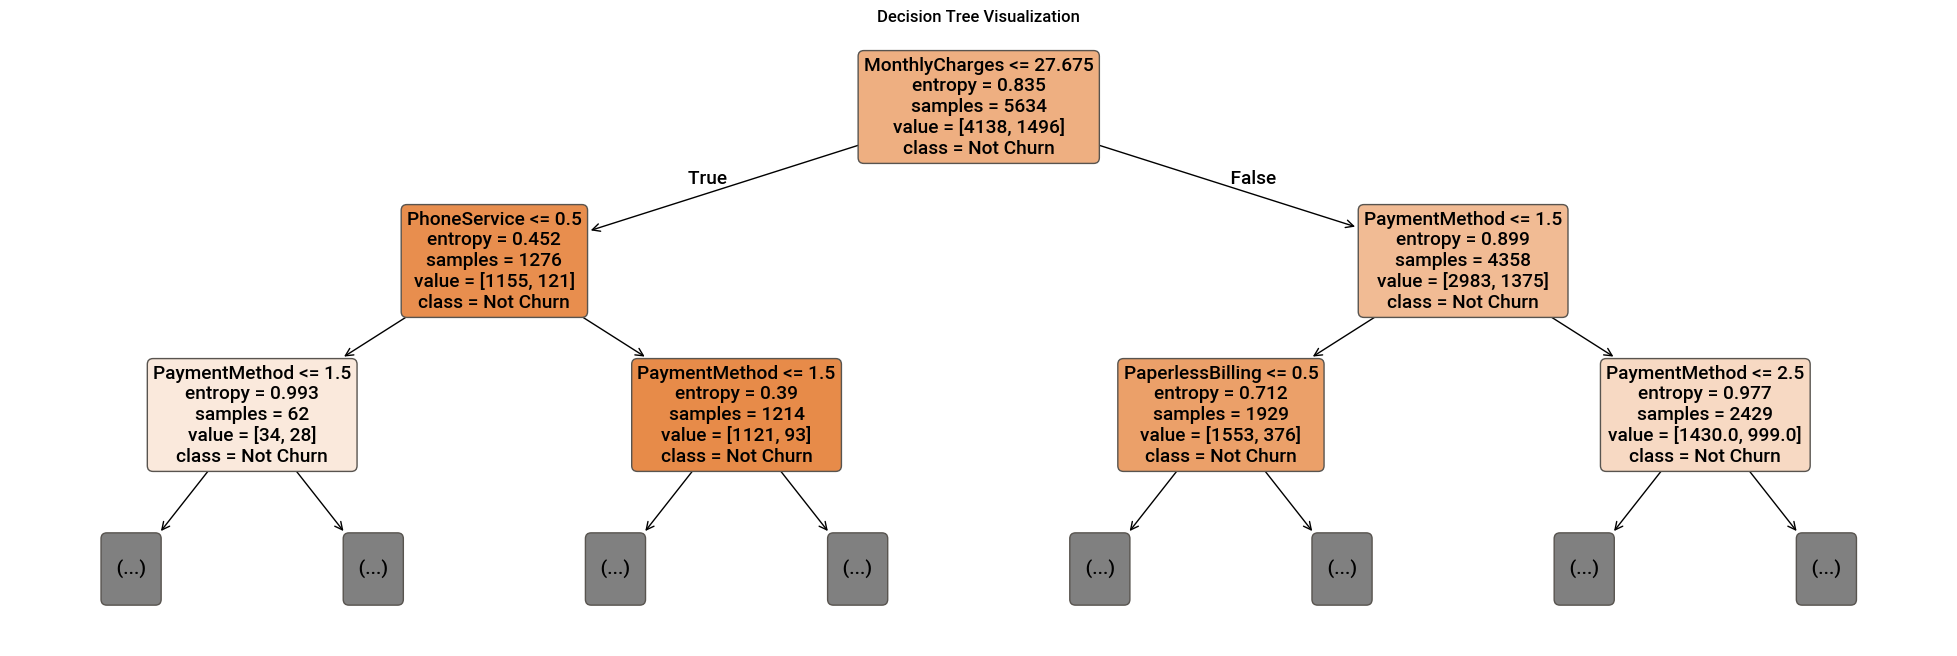

In [43]:
from sklearn.tree import plot_tree
plt.figure(figsize = (25,8))
plot_tree(dt, filled = True, feature_names = x_train.columns, max_depth = 2, class_names = ["Not Churn", "Churn"], rounded = True)
plt.title("Decision Tree Visualization")
plt.show()

# Cross Validation

In [45]:
from sklearn.model_selection import cross_val_score

In [52]:
cv_scores = cross_val_score(dt, x, y, cv = 17, scoring = 'accuracy')

In [53]:
print(f"Accuracy for each fold: {cv_scores}")

Accuracy for each fold: [0.71084337 0.6939759  0.66987952 0.70120482 0.67228916 0.72222222
 0.70048309 0.70531401 0.68599034 0.69323671 0.68599034 0.6763285
 0.6763285  0.70772947 0.68115942 0.69806763 0.67874396]


# Stratified K Fold Cross Validation

In [54]:
from sklearn.model_selection import StratifiedKFold

In [58]:
skf = StratifiedKFold(n_splits = 10, shuffle = True, random_state = 42)
cv_scores = cross_val_score(dt, x, y, cv = skf, scoring = 'accuracy')


In [59]:
print(f"Accuracy for each fold: {cv_scores}")

Accuracy for each fold: [0.69361702 0.72198582 0.70780142 0.66761364 0.68181818 0.67471591
 0.66193182 0.69176136 0.67471591 0.71590909]


In [61]:
print(f"Mean Accuracy: {np.mean(cv_scores)}")
print(f"Standard Deviation of Accuracy: {np.std(cv_scores):.4f}")

Mean Accuracy: 0.6891870164410058
Standard Deviation of Accuracy: 0.0196


# Cross Validation on other metrices(Precision, Recall, F1 Score

In [64]:
precision_scores = cross_val_score(dt, x, y, cv = 5, scoring = 'precision')
recall_scores = cross_val_score(dt,x, y, cv = 5, scoring = 'recall')
f1_scores = cross_val_score(dt, x, y , cv = 5, scoring = 'f1')


print(f"Precision for each fold: {precision_scores}")
print(f"Recall for each fold: {recall_scores}")
print(f"F1-score for each fold: {f1_scores}")


print(f"Mean Precision: {np.mean(precision_scores):.4f}, Std: {np.std(precision_scores):.4f}")
print(f"Mean Recall: {np.mean(recall_scores):.4f}, Std: {np.std(recall_scores):.4f}")
print(f"Mean F1-score: {np.mean(f1_scores):.4f}, Std: {np.std(f1_scores):.4f}")

Precision for each fold: [0.39308176 0.40184049 0.41945289 0.38244514 0.4       ]
Recall for each fold: [0.3342246  0.35026738 0.36898396 0.32707775 0.37433155]
F1-score for each fold: [0.36127168 0.37428571 0.39260313 0.35260116 0.38674033]
Mean Precision: 0.3994, Std: 0.0121
Mean Recall: 0.3510, Std: 0.0186
Mean F1-score: 0.3735, Std: 0.0150


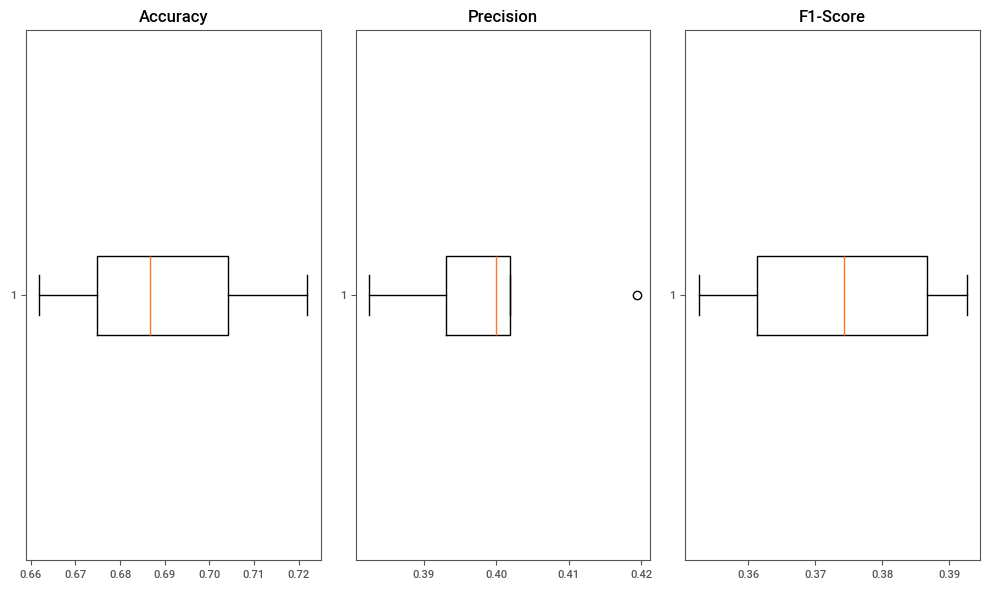

In [65]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 3, 1)
plt.boxplot([cv_scores], vert=False)
plt.title('Accuracy')

plt.subplot(1, 3, 2)
plt.boxplot([precision_scores], vert=False)
plt.title('Precision')

plt.subplot(1, 3, 3)
plt.boxplot([f1_scores], vert=False)
plt.title('F1-Score')

plt.tight_layout()
plt.show()